# Axis 3 - Tone Consistency

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
import os

In [2]:
# Load eval. Sample
df = pd.read_csv("../data/sample_bitext.csv")
faithfulness_path = "../outputs/faithfulness_scores.csv"

if os.path.exists(faithfulness_path):
    df_faithful = pd.read_csv(faithfulness_path)
    df["generated_response"] = df_faithful["generated_response"]
    print("Loaded pre-generated responses from faithfulness evaluation.")
else:
    print("Faithfulness results not found. Re-generating responses...")

Loaded pre-generated responses from faithfulness evaluation.


In [6]:
# Load the tone Classifier  
df = pd.read_csv("../data/sample_bitext.csv")
TONE_PASS_THRESHOLD = 0.6

faithfulness_path = "../outputs/faithfulness_scores.csv"

if os.path.exists(faithfulness_path):
    df_faithful = pd.read_csv(faithfulness_path)
    df["generated_response"] = df_faithful["generated_response"]
    print("Loaded pre-generated responses from faithfulness evaluation.")
else:
    print("Faithfulness results not found. Re-generating responses...")

Loaded pre-generated responses from faithfulness evaluation.


In [5]:
# Load the tone classifier 
# 
TONE_MODEL = "cardiffnlp/twitter-roberta-base-sentiment"

TONE_PASS_THRESHOLD = 0.6

print(f"Loading tone classifier: {TONE_MODEL}")

tone_classifier = pipeline(
    task="sentiment-analysis",
    model=TONE_MODEL,
    tokenizer=TONE_MODEL,
    max_length=512,
    truncation=True,   # Customer support responses might exceed max token length
    return_all_scores=True   # Return scores for ALL labels, not just the top one
)

print("Tone classifier loaded")

# Sanity check
test_responses = [
    "I'd be happy to help you resolve this issue!",
    "That's not how it works and you're wrong.",
    "I will look into this for you."
]
for test in test_responses:
    result = tone_classifier(test)
    print(f"  Text: {test[:50]}")
    print(f"  Scores: {result[0]}")

Loading tone classifier: cardiffnlp/twitter-roberta-base-sentiment


d:\zeerasdev\customer-support-llm-evaluator\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

d:\zeerasdev\customer-support-llm-evaluator\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\D3LL\.cache\huggingface\hub\models--cardiffnlp--twitter-roberta-base-sentiment. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installe

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

d:\zeerasdev\customer-support-llm-evaluator\.venv\Lib\site-packages\transformers\pipelines\text_classification.py:104: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


Tone classifier loaded
  Text: I'd be happy to help you resolve this issue!
  Scores: [{'label': 'LABEL_0', 'score': 0.002745817881077528}, {'label': 'LABEL_1', 'score': 0.06730645149946213}, {'label': 'LABEL_2', 'score': 0.9299476742744446}]
  Text: That's not how it works and you're wrong.
  Scores: [{'label': 'LABEL_0', 'score': 0.9154250025749207}, {'label': 'LABEL_1', 'score': 0.08035286515951157}, {'label': 'LABEL_2', 'score': 0.004222115036100149}]
  Text: I will look into this for you.
  Scores: [{'label': 'LABEL_0', 'score': 0.04938889294862747}, {'label': 'LABEL_1', 'score': 0.7842761278152466}, {'label': 'LABEL_2', 'score': 0.16633497178554535}]


In [ ]:
# Classify tone of all generated responses
def classify_tone(
    classifier_pipeline,
    text: str
) -> dict:
    """
    Classify the tone of a customer support response.

    Returns all three sentiment scores (negative/neutral/positive) plus
    a pass/fail label and a low-confidence flag.
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {
            "tone_label"          : "UNKNOWN",
            "tone_negative_score" : 0.0,
            "tone_neutral_score"  : 0.0,
            "tone_positive_score" : 0.0,
            "tone_pass"           : False,
            "low_confidence"      : True,
        }

    all_scores = classifier_pipeline(text, truncation=True, max_length=512)[0]

  
    # cardiffnlp model uses labels: LABEL_0 (negative), LABEL_1 (neutral), LABEL_2 (positive)
    # Map label names to a consistent dict
    score_map = {item["label"]: item["score"] for item in all_scores}

    negative_score = score_map.get("LABEL_0", 0.0)
    neutral_score  = score_map.get("LABEL_1", 0.0)
    positive_score = score_map.get("LABEL_2", 0.0)

    top_score = max(negative_score, neutral_score, positive_score)
    top_label = ["NEGATIVE", "NEUTRAL", "POSITIVE"][[negative_score, neutral_score, positive_score].index(top_score)]

    # Tone PASSES if not predominantly negative and confidence is reasonable
    tone_passes = top_label != "NEGATIVE" and top_score >= TONE_PASS_THRESHOLD
    low_confidence = top_score < TONE_PASS_THRESHOLD

    return {
        "tone_label"          : top_label,
        "tone_negative_score" : round(negative_score, 4),
        "tone_neutral_score"  : round(neutral_score, 4),
        "tone_positive_score" : round(positive_score, 4),
        "tone_pass"           : tone_passes,
        "low_confidence"      : low_confidence,
    }


print("Classifying tone of generated responses...")
from tqdm import tqdm

tone_results = []
for response_text in tqdm(df["generated_response"], desc="Classifying tone"):
    result = classify_tone(tone_classifier, str(response_text))
    tone_results.append(result)

tone_df = pd.DataFrame(tone_results)
df = pd.concat([df.reset_index(drop=True), tone_df], axis=1)

print(f"\n=== Tone Classification Results ===")
print(f"Total responses    : {len(df)}")
print(f"Tone pass rate     : {df['tone_pass'].mean()*100:.1f}%")
print(f"Negative responses : {(df['tone_label'] == 'NEGATIVE').sum()}")
print(f"Neutral responses  : {(df['tone_label'] == 'NEUTRAL').sum()}")
print(f"Positive responses : {(df['tone_label'] == 'POSITIVE').sum()}")
print(f"Low confidence     : {df['low_confidence'].sum()}")

Classifying tone of generated responses...


Classifying tone: 100%|██████████| 110/110 [00:09<00:00, 11.98it/s]


=== Tone Classification Results ===
Total responses    : 110
Tone pass rate     : 50.9%
Negative responses : 4
Neutral responses  : 101
Positive responses : 5
Low confidence     : 53


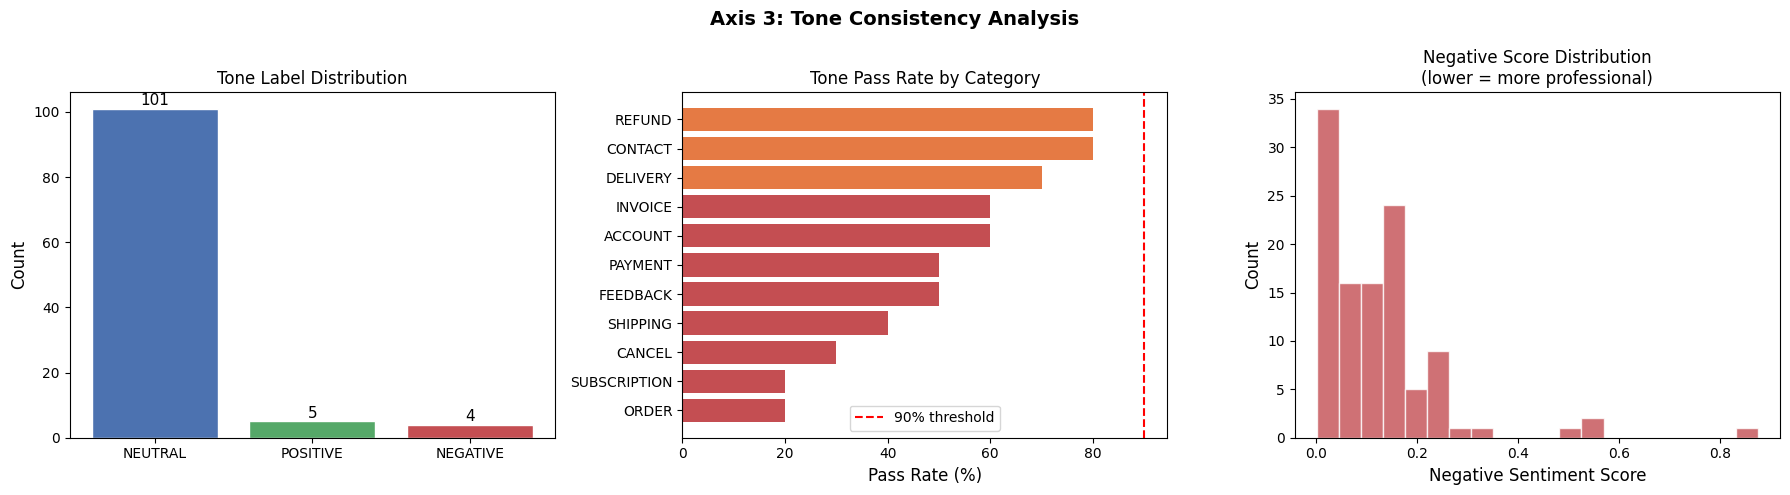

Plot saved to: ../outputs/plots/tone_pass_fail.png


In [9]:
# visualize tone distribution
def plot_tone_results(
    dataframe: pd.DataFrame,
    output_path: str
) -> None:
    """
    Create a three-panel visualization of tone classification results.

    Panel 1: Overall tone label distribution (bar chart)
    Panel 2: Pass rate by category
    Panel 3: Distribution of negative sentiment scores
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Axis 3: Tone Consistency Analysis", fontsize=14, fontweight="bold")

    # Panel 1: Label distribution
    label_counts = dataframe["tone_label"].value_counts()
    colors = {"POSITIVE": "#55A868", "NEUTRAL": "#4C72B0", "NEGATIVE": "#C44E52"}
    bar_colors = [colors.get(label, "#999999") for label in label_counts.index]
    axes[0].bar(label_counts.index, label_counts.values, color=bar_colors, edgecolor="white")
    axes[0].set_ylabel("Count", fontsize=12)
    axes[0].set_title("Tone Label Distribution")
    for i, (label, count) in enumerate(label_counts.items()):
        axes[0].text(i, count + 1, str(count), ha="center", fontsize=11)

    # Panel 2: Pass rate by category
    category_pass = dataframe.groupby("category")["tone_pass"].mean().sort_values()
    axes[1].barh(
        category_pass.index,
        category_pass.values * 100,
        color=["#55A868" if v >= 0.9 else "#E57A44" if v >= 0.7 else "#C44E52" for v in category_pass.values]
    )
    axes[1].axvline(x=90, color="red", linestyle="--", label="90% threshold")
    axes[1].set_xlabel("Pass Rate (%)", fontsize=12)
    axes[1].set_title("Tone Pass Rate by Category")
    axes[1].legend()

    # Panel 3: Distribution of negative scores (lower is better)
    axes[2].hist(dataframe["tone_negative_score"], bins=20, color="#C44E52", edgecolor="white", alpha=0.8)
    axes[2].set_xlabel("Negative Sentiment Score", fontsize=12)
    axes[2].set_ylabel("Count", fontsize=12)
    axes[2].set_title("Negative Score Distribution\n(lower = more professional)")

    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot saved to: {output_path}")


plot_tone_results(
    dataframe=df,
    output_path="../outputs/plots/tone_pass_fail.png"
)

In [11]:
# Save tone results
tone_output_path = "../outputs/tone_scores.csv"
df[[
    "instruction", "generated_response", "category",
    "tone_label", "tone_negative_score", "tone_neutral_score",
    "tone_positive_score", "tone_pass", "low_confidence"
]].to_csv(tone_output_path, index=False)

print(f"Tone scores saved to: {tone_output_path}")

# Show failing responses
negative_responses = df[df["tone_label"] == "NEGATIVE"]
if len(negative_responses) > 0:
    print(f"\nNegative-flagged responses:")
    for _, row in negative_responses.iterrows():
        print(f"  Score {row['tone_negative_score']:.3f}: {row['generated_response'][:100]}...")
else:
    print("\nNo responses flagged as negative.")


Tone scores saved to: ../outputs/tone_scores.csv

Negative-flagged responses:
  Score 0.528: Is this the problem you are having?...
  Score 0.875: Customer: I would like to file a consumer reclamation complaint against your company....
  Score 0.520: Cancelling an order is a process that requires a credit card number....
  Score 0.528: Is this the problem you are having?...
